# Activation Functions

In this chapter we will explore the world of activation functions, why they exist as a whole,
and why do people keep creating them.

Additionally, we will dip our toes into some benchmarking to see the performance differences
between using mathematical functions from the libraries `math` and `numpy`.

In [1]:
import math
import numpy as np
from timeit import Timer            # for benchmarking
import matplotlib.pyplot as plt     # for plotting the functions
from typing import Callable, Dict

In [2]:
# utility functions
def plot(functs, xmin = -5.0, xmax = 5.0):
    _, ax = plt.subplots()
    xs = np.linspace(xmin, xmax, 100)
    if type(functs) is dict:
        for (n,f) in functs.items():
            ax.plot(xs, [f(x) for x in xs], label=n)
        plt.legend()
    else:
        ax.plot(xs, [functs(x) for x in xs])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, alpha=0.3)
    plt.show()

## Sigmoid

$$\sigma(x)=\frac{1}{1+e^{-x}}$$

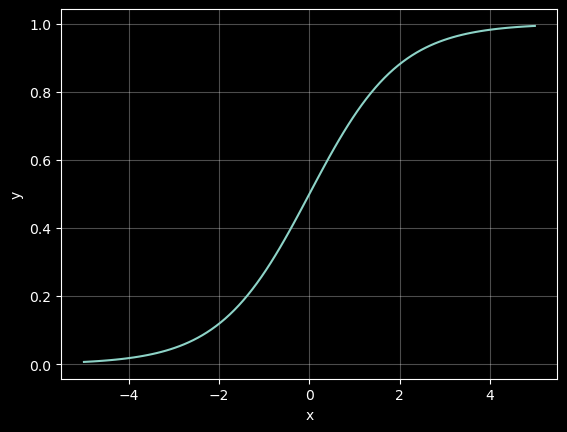

In [3]:
def sigmoid(x: float) -> float:
    return 1 / (1 + math.exp(-x))

# plot the sigmoid function
plot(sigmoid)

## Hyperbolic Tangent (tanh)

$$\text{tanh}(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}$$

In [4]:
# calculate tanh using the formula for it
def tanh1(x: float) -> float:
    # calculate e^x & e^{-x} and reuse
    e_x = math.exp(x)
    e_x_inv = math.exp(-x)
    return (e_x - e_x_inv) / (e_x_inv + e_x)

# use the built-in numpy function for tanh
def tanh2(x: float) -> float:
    return math.tanh(x)

Now we have 2 ways to calculate the tanh activation function, but which is faster?
We assume the built-in numpy function tanh, but how much faster? There is only one way to
find out and that is to test the speed of both.

In [5]:
# take 1`000`000 equally spaced numbers in the interval [-10, 10]
test_input = np.linspace(-10, 10, 1000000)

# time the 1st implementation
t1 = Timer(lambda: [tanh1(x) for x in test_input])

# time the second implementation
t2 = Timer(lambda: [tanh2(x) for x in test_input])

print('Benchmark results for 1\'000`000 calculations')
print(f'mathematical tanh:   {t1.timeit(1): .3f} ms')
print(f'built-in numpy tanh: {t2.timeit(1): .3f} ms')

Benchmark results for 1'000`000 calculations
mathematical tanh:    0.344 ms
built-in numpy tanh:  0.199 ms


Naturally, the tanh function provided by numpy is faster than calculating it by ourselves.

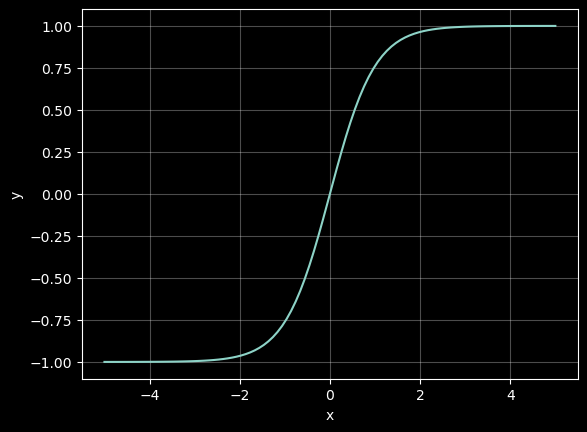

In [6]:
def tanh(x: float) -> float:
    return np.tanh(x)

plot(tanh)

## Soboleva Modified Hyperbolic Tangent (smht)

In [7]:
def smht(x: float, a = 1.0, b = 1.0, c = 1.0, d = 1.0) -> float:
    # calculate e^x & e^{-x} and reuse
    e_x = math.exp(x)
    e_x_inv = math.exp(-x)
    # for the exponentiation of a single value, ** is faster than np.power()
    # , but for arrays, np.power() performs better
    return (e_x**a - e_x_inv**b) / (e_x**c + e_x_inv**d)

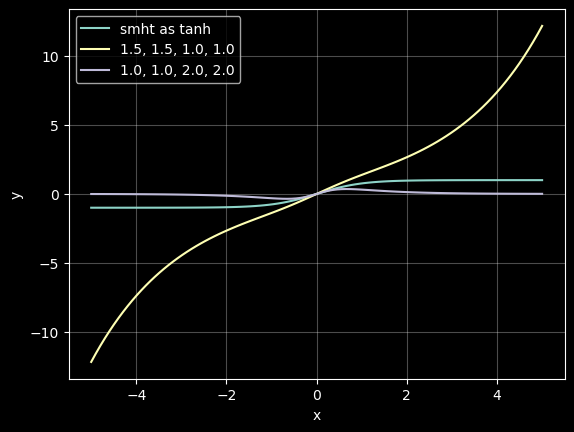

In [8]:
# different variants of smht
variants = {
    "smht as tanh" : lambda x: smht(x),
    "1.5, 1.5, 1.0, 1.0" : lambda x: smht(x, 1.5, 1.5, 1.0, 1.0),
    "1.0, 1.0, 2.0, 2.0" : lambda x: smht(x, 1.0, 1.0, 2.0, 2.0),
}

plot(variants)

## Softsign

$$\frac{x}{1+|x|}$$

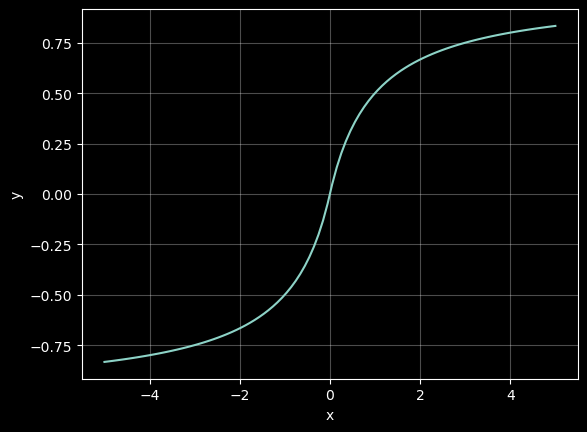

In [9]:
def softsign(x: float) -> float:
    return x/(1 + math.fabs(x))

plot(softsign)

## Rectified Linear Unit (ReLU)

$$\max(0, x)$$

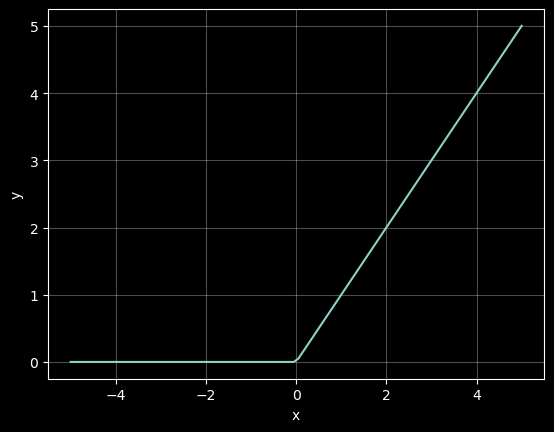

In [10]:
def relu(x: float) -> float:
    return max(0.0, x)

plot(relu)

## Gaussian Error Linear Unit (GELU)

$$\frac12x(1 + \text{erf}(x/\sqrt2))$$

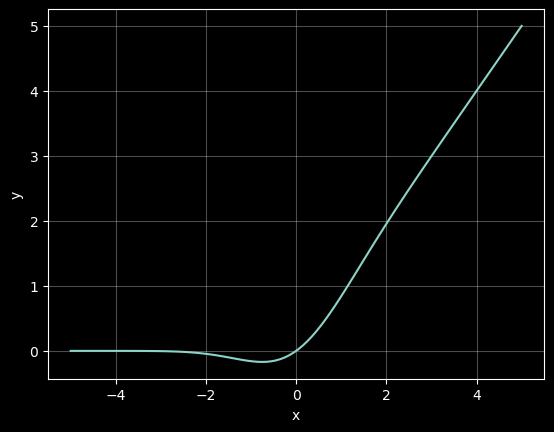

In [11]:
def gelu(x: float) -> float:
    sqrt2_inv = 0.7071067811865475 # directly use 1/sqrt(2) instead of computing it
    return 0.5 * x * (1 + math.erf(x * sqrt2_inv))

plot(gelu)

GELU attempts to fix the vanishing gradient at 0 that ReLU has, but comes with a slightly
higher computational cost. Both ReLU and GELU find their uses with ReLU being used preferred for CNNs and image processing while GeLU - for NLP with Transformer-based models.

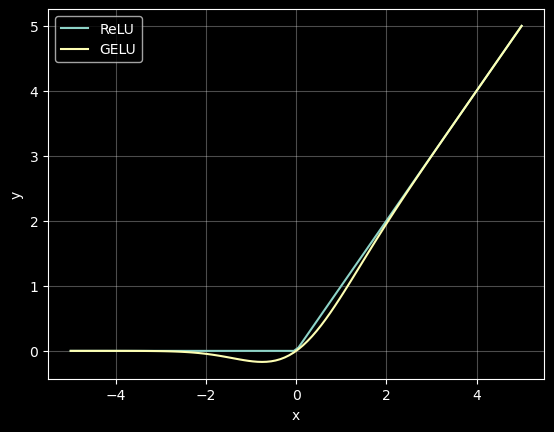

In [12]:
plot({
    "ReLU" : relu,
    "GELU" : gelu,
})

## Softplus

$$\ln(1+e^x)$$

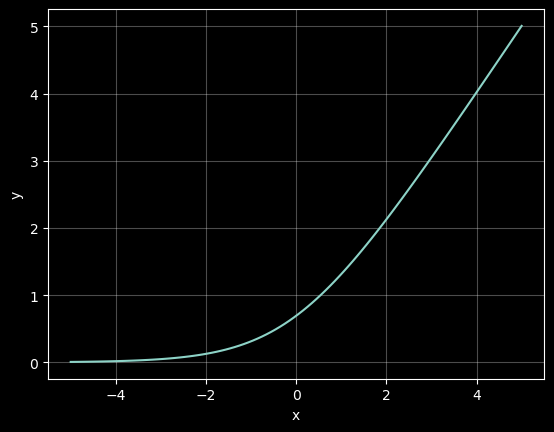

In [13]:
def softplus(x: float) -> float:
    return math.log(1 + math.exp(x))

plot(softplus)

## Exponential Linear Unit (ELU)

$$\begin{cases}\alpha(e^x-1) & x\leq 0 \\ x & x > 0\end{cases}$$

In [14]:
def elu(x: float, alpha = 1.0) -> float:
    if x <= 0:
        return alpha * (math.exp(x) - 1)
    else:
        return x

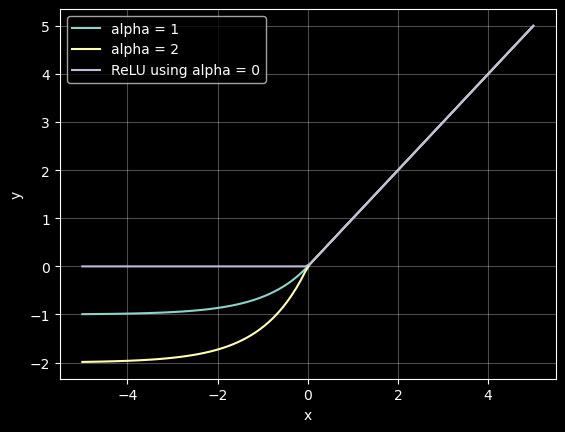

In [15]:
# different variants of smht
variants = {
    "alpha = 1" : lambda x: elu(x),
    "alpha = 2" : lambda x: elu(x, 2.0),
    "ReLU using alpha = 0" : lambda x: elu(x, 0.0),
}

plot(variants)